# 7 - La Distribuzione Normale con R

Questo notebook esplora la **distribuzione normale** (o gaussiana):
1. **Generazione di valori normali** — `rnorm()`
2. **Confronto tra diverse normali** — variando media e deviazione standard
3. **Standardizzazione (Z-score)** — trasformazione in normale standard
4. **Calcolo di aree (probabilità)** — `pnorm()`
5. **Confronto tra distribuzione originale e standardizzata**
6. **Applicazione al dataset Iris**

---
## 1. Distribuzione Normale Standard

La **normale standard** ha media $\mu = 0$ e deviazione standard $\sigma = 1$.
Generiamo 100.000 valori con `rnorm(n, media, sd)`.

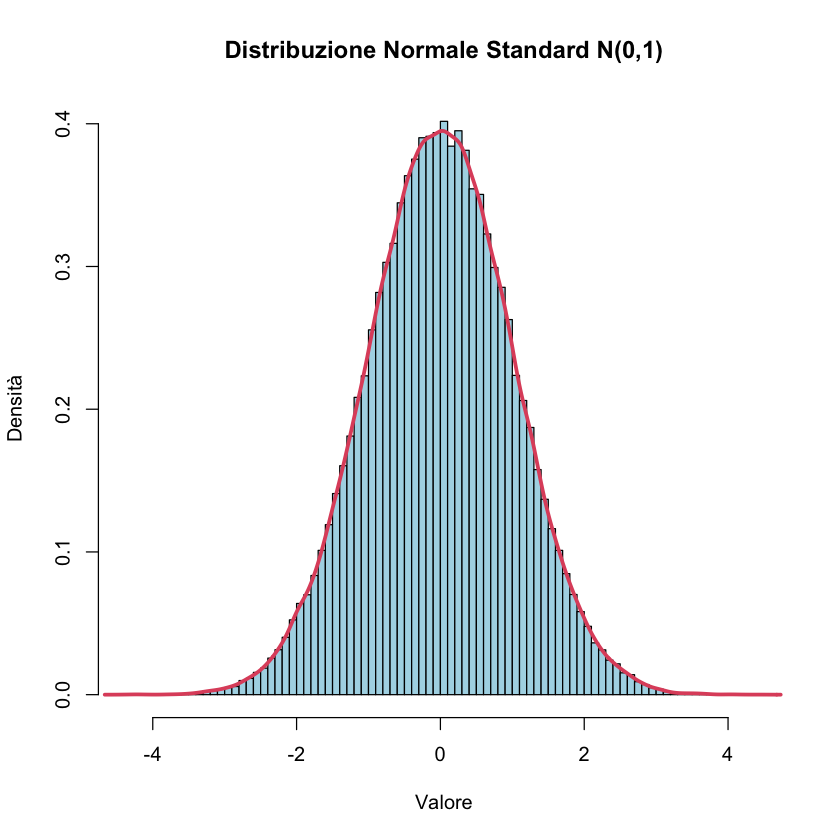

In [1]:
# Generiamo 100.000 valori da una normale standard N(0,1)
normale_standard <- rnorm(100000, 0, 1)

# Istogramma con densità
hist(normale_standard, freq = FALSE, breaks = 100,
     main = "Distribuzione Normale Standard N(0,1)",
     xlab = "Valore", ylab = "Densità",
     col = "lightblue")

# Curva di densità (stima kernel)
lines(density(normale_standard), col = 2, lwd = 3)

---
## 2. Confronto tra Diverse Normali

Confrontiamo tre distribuzioni normali con parametri diversi:
- **N(0,1)** — normale standard (curva nera)
- **N(5,2)** — media 5, deviazione standard 2 (curva rossa)
- **N(5,1.5)** — media 5, deviazione standard 1.5 (curva verde)

Più la deviazione standard è piccola, più la curva è "stretta" e alta.

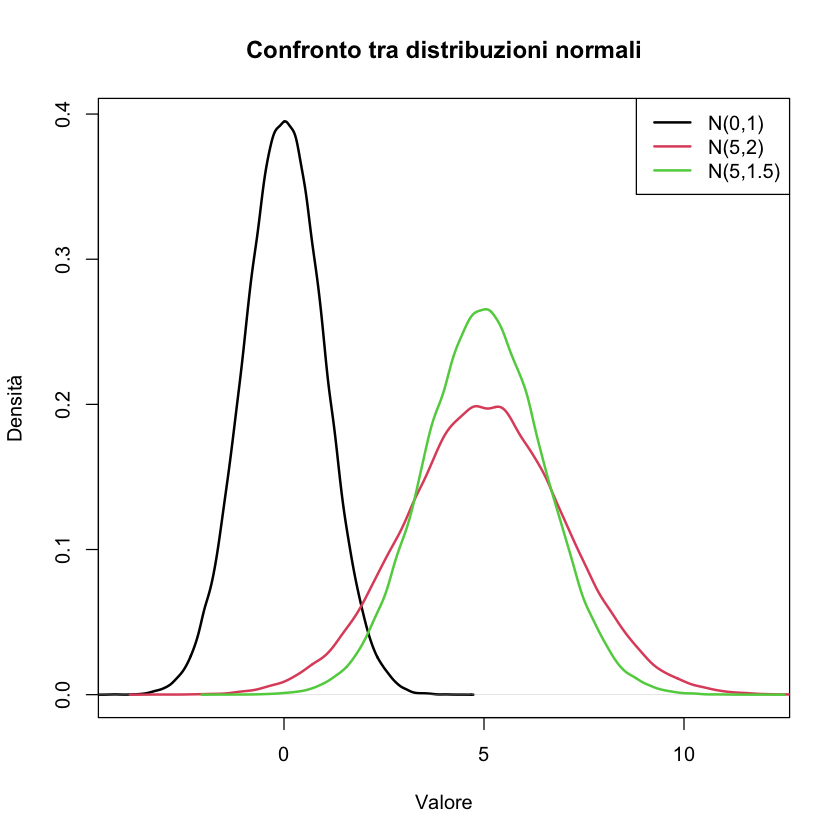

In [2]:
# Densità della normale standard (già generata)
plot(density(normale_standard), xlim = c(-4, 12),
     main = "Confronto tra distribuzioni normali",
     xlab = "Valore", ylab = "Densità",
     col = 1, lwd = 2)

# Normale con media 5 e deviazione standard 2
normale_5_2 <- rnorm(100000, 5, 2)
lines(density(normale_5_2), col = 2, lwd = 2)

# Normale con media 5 e deviazione standard 1.5
normale_5_1.5 <- rnorm(100000, 5, 1.5)
lines(density(normale_5_1.5), col = 3, lwd = 2)

legend("topright", legend = c("N(0,1)", "N(5,2)", "N(5,1.5)"),
       col = c(1, 2, 3), lwd = 2)

---
## 3. Standardizzazione (Z-score)

La **standardizzazione** trasforma una distribuzione normale generica in una normale standard:
$$Z = \frac{X - \mu}{\sigma}$$

Standardizziamo la N(5,2) e verifichiamo che la sua densità coincide con la N(0,1).

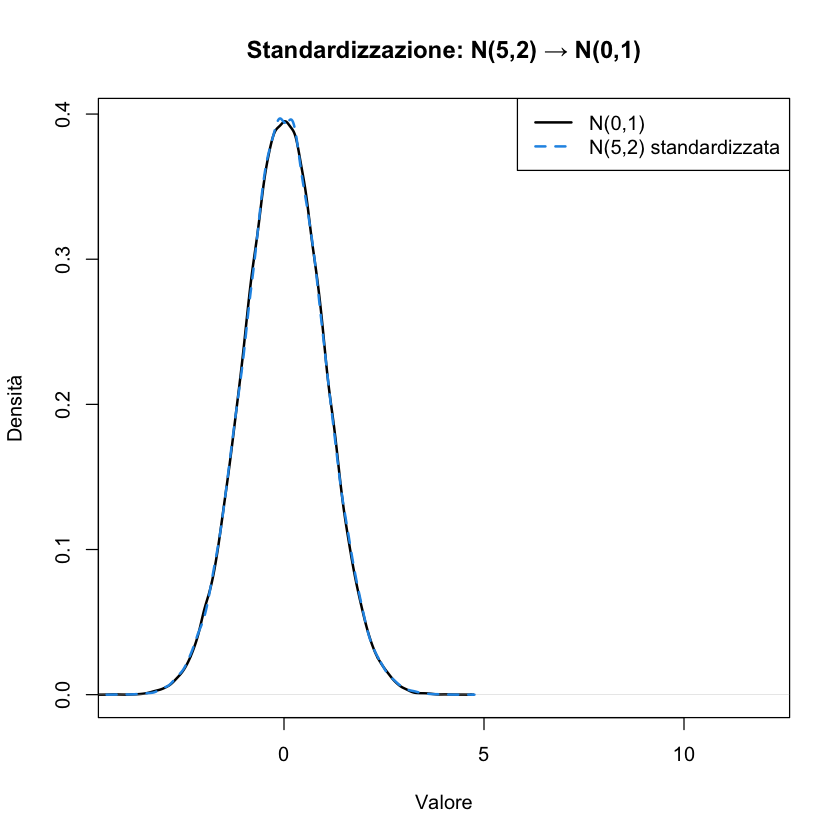

In [3]:
# Standardizzazione della N(5,2)
Z <- (normale_5_2 - mean(normale_5_2)) / sd(normale_5_2)

# Sovrapponiamo la densità della Z standardizzata alla N(0,1)
plot(density(normale_standard), xlim = c(-4, 12),
     main = "Standardizzazione: N(5,2) → N(0,1)",
     xlab = "Valore", ylab = "Densità",
     col = 1, lwd = 2)
lines(density(Z), col = 4, lwd = 2, lty = 2)
legend("topright", legend = c("N(0,1)", "N(5,2) standardizzata"),
       col = c(1, 4), lwd = 2, lty = c(1, 2))

---
## 4. Calcolo di Aree (Probabilità) con pnorm()

La funzione `pnorm(q, media, sd)` calcola la **funzione di ripartizione** (CDF):
restituisce $P(X \leq q)$, cioè l'area sotto la curva a sinistra di `q`.

Esempio: distribuzione delle **altezze** con $\mu = 170$ cm e $\sigma = 10$ cm.

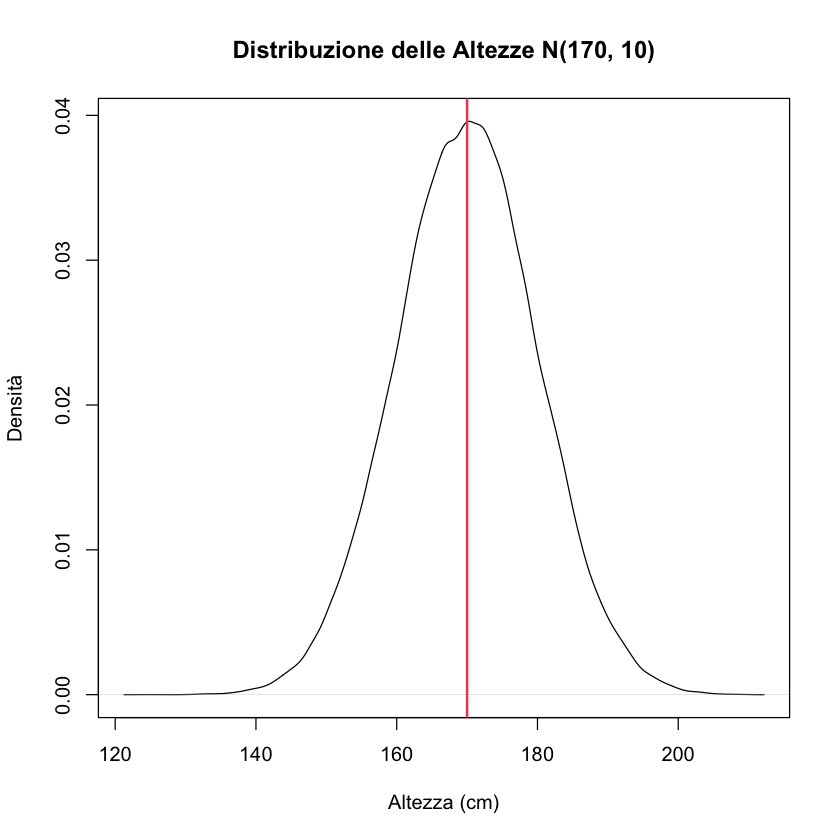

In [4]:
# Parametri della distribuzione delle altezze
mu <- 170
sigma <- 10

# Generiamo 100.000 valori
altezza <- rnorm(100000, mu, sigma)

# Densità delle altezze
plot(density(altezza),
     main = "Distribuzione delle Altezze N(170, 10)",
     xlab = "Altezza (cm)", ylab = "Densità")
abline(v = mu, col = 2, lwd = 2)  # linea per la media

In [5]:
# P(altezza <= 170) = 0.5 (la media è il 50° percentile)
pnorm(170, mu, sigma)

# P(altezza <= 155) = ?
pnorm(155, mu, sigma)

# P(altezza > 155) = 1 - P(altezza <= 155)
1 - pnorm(155, mu, sigma)

# P(altezza > 198) = ?
1 - pnorm(198, mu, sigma)

[1] 0.5

[1] 0.0668072

[1] 0.9331928

[1] 0.00255513

### Probabilità in un intervallo

Calcoliamo $P(167 \leq X \leq 189)$, cioè l'area tra due valori.

[1] 0.5891949

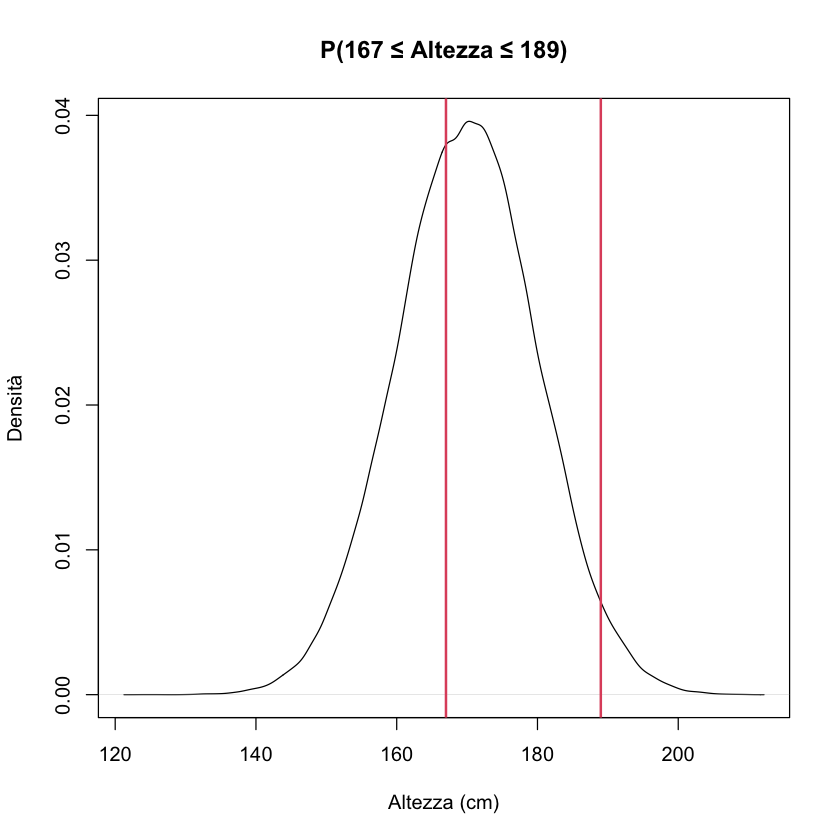

In [6]:
# Visualizziamo l'intervallo [167, 189]
plot(density(altezza),
     main = "P(167 ≤ Altezza ≤ 189)",
     xlab = "Altezza (cm)", ylab = "Densità")
abline(v = 167, col = 2, lwd = 2)
abline(v = 189, col = 2, lwd = 2)

# P(167 <= X <= 189) = P(X <= 189) - P(X <= 167)
pnorm(189, mu, sigma) - pnorm(167, mu, sigma)

---
## 5. Confronto tra Distribuzione Originale e Standardizzata

Standardizziamo le altezze e verifichiamo che la probabilità calcolata sulla distribuzione originale equivale a quella calcolata sulla Z.

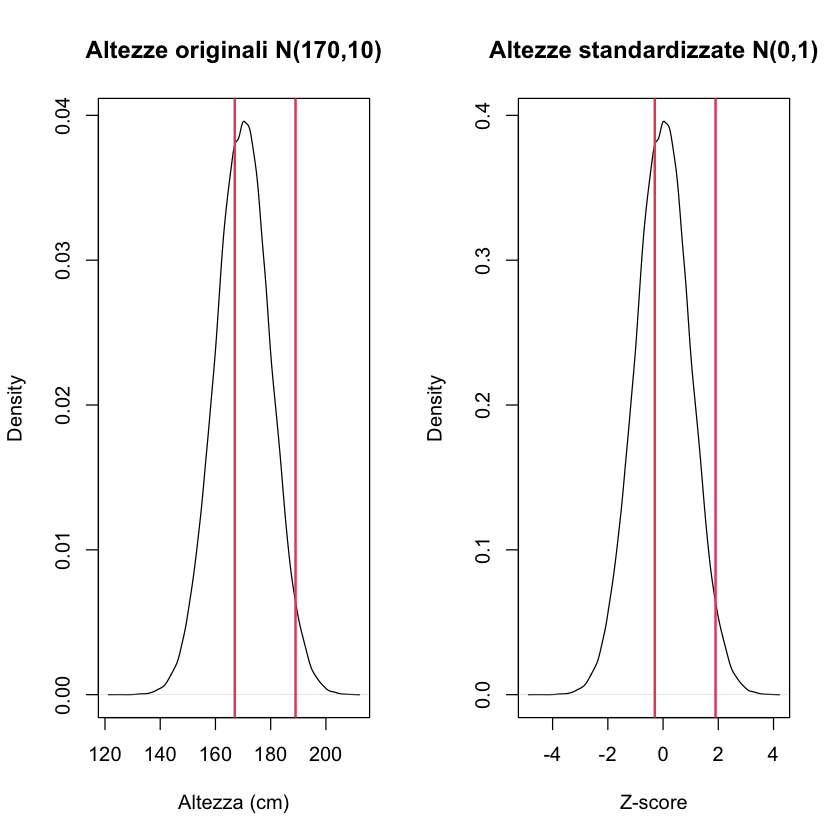

In [7]:
# Standardizzazione
altezza_stnd <- (altezza - mu) / sigma

# Z-score per 167 e 189
Z189 <- (189 - mu) / sigma
Z167 <- (167 - mu) / sigma

# Grafico affiancato
par(mfrow = c(1, 2))

# Distribuzione originale
plot(density(altezza),
     main = "Altezze originali N(170,10)",
     xlab = "Altezza (cm)")
abline(v = 167, col = 2, lwd = 2)
abline(v = 189, col = 2, lwd = 2)

# Distribuzione standardizzata
plot(density(altezza_stnd),
     main = "Altezze standardizzate N(0,1)",
     xlab = "Z-score")
abline(v = Z167, col = 2, lwd = 2)
abline(v = Z189, col = 2, lwd = 2)

In [8]:
# La probabilità è la stessa!
pnorm(189, mu, sigma) - pnorm(167, mu, sigma)
pnorm(Z189, 0, 1) - pnorm(Z167, 0, 1)

[1] 0.5891949

[1] 0.5891949

---
## 6. Applicazione al Dataset Iris

Visualizziamo la distribuzione di `Petal.Length` dal dataset `iris` e confrontiamola con una normale.

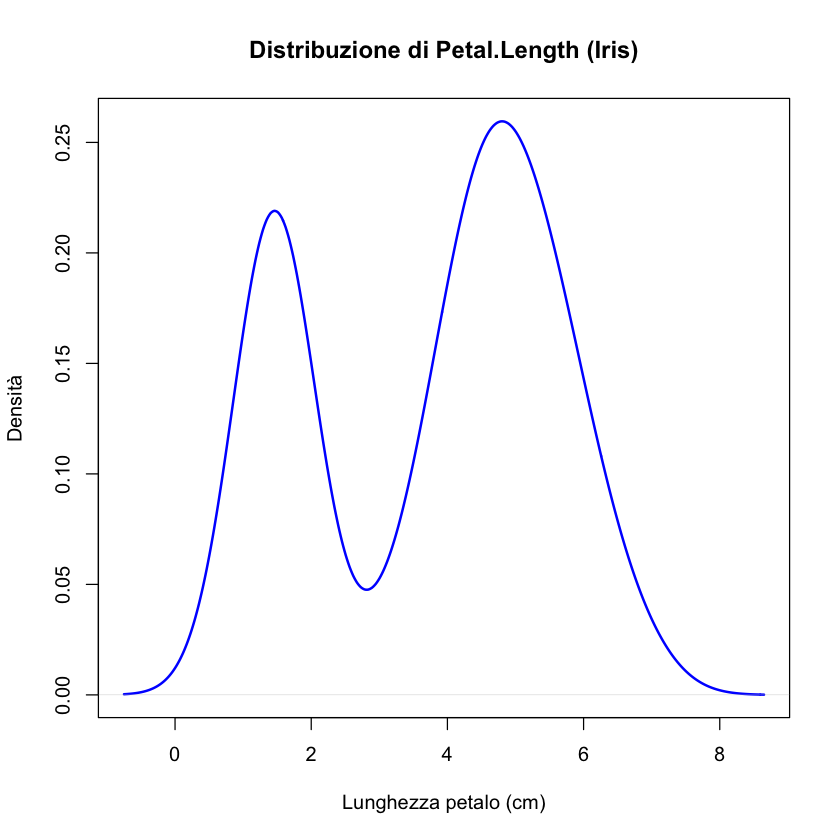

In [9]:
# Carichiamo iris
data("iris")

# Densità di Petal.Length
plot(density(iris$Petal.Length),
     main = "Distribuzione di Petal.Length (Iris)",
     xlab = "Lunghezza petalo (cm)", ylab = "Densità",
     col = "blue", lwd = 2)

**Petal.Length** nel dataset Iris è un classico esempio di distribuzione **bimodale** (due picchi):

- **Primo picco** (~1.5 cm): corrisponde alla specie **setosa** (petali corti)
- **Secondo picco** (~4-5 cm): corrisponde alle specie **versicolor** e **virginica** (petali più lunghi)

La distribuzione ha due "gobbe" perché stai mischiando gruppi diversi con caratteristiche diverse.

---

**La differenza con coin × dice × dice:**

| Distribuzione | Numero di picchi | Causa |
|---|---|---|
| Petal.Length (Iris) | **Bimodale** (2 picchi) | Due gruppi di specie con petali di lunghezze diverse |
| coin × dice × dice | **Multi-modale** (molti picchi) | Il prodotto di tre variabili discrete crea molti valori con frequenze diverse |

Nel caso del coin × dice × dice, i "picchi" sono più numerosi e meno pronunciati perché derivano dalla combinazione di molti possibili prodotti (3×a×b e 6×a×b), alcuni dei quali si ripetono più spesso di altri.

Quindi sì, hai ragione: Petal.Length è bimodale, mentre coin × dice × dice è multi-modale. Entrambe sono distribuzioni che **non** seguono una normale (gaussiana).